In [1]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import re
from math import ceil
from scipy.stats import norm
from matplotlib import cm
from matplotlib.colors import Normalize

import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tissue_enrichment as te

Identify which tissue specific isoforms are enriched and depleted
-
the stat (Wald/t) from DESeq2 already balances effect size and uncertainty. use this as the combined score for the weighted enrichment

only the transcripts that were significantly altered from the assay are included in this analysis 

In [2]:
data = pd.read_csv("applied_depletion_gregor_n100/rsem/DESeq2_D_vs_WM_paired_results_isoforms_with_means.csv")
data['significant'] = np.where(data['padj'] < 0.05, 'significant', 'not significant')
data['Transcript stable ID'] = data['transcript_id'].str.split('.').str[0]  
data['-log10(pvalue)'] = -np.log10(data['pvalue'])
data['-log10(pvalue)'] = data['-log10(pvalue)'].replace([np.inf, -np.inf], 300)
data

/Users/jbezney/miniforge3/envs/pegasus/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,transcript_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,mean_WM_norm,mean_D_norm,mean_WM_model,mean_D_model,significant,Transcript stable ID,-log10(pvalue)
0,ENST00000684628.1,630.096376,1.061378,0.020370,52.104103,0.000000,0.0,407.365690,852.827061,410.077980,885.330870,significant,ENST00000684628,300.000000
1,ENST00000374003.7,230.221361,-2.913648,0.047160,-61.782624,0.000000,0.0,405.406313,55.036409,417.266456,58.460144,significant,ENST00000374003,300.000000
2,ENST00000374004.5,248.089106,-5.191762,0.126386,-41.078678,0.000000,0.0,480.348104,15.830107,527.299344,15.225122,significant,ENST00000374004,300.000000
3,ENST00000374005.8,6619.387425,-2.240697,0.018445,-121.481335,0.000000,0.0,10912.262825,2326.512024,10906.612727,2416.802316,significant,ENST00000374005,300.000000
4,ENST00000399173.5,1363.700609,-3.283663,0.042424,-77.401034,0.000000,0.0,2464.908649,262.492569,2522.719125,269.535298,significant,ENST00000399173,300.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178322,ENST00000845964.1,0.326832,0.201177,2.898460,0.069408,0.944665,NaN,0.194736,0.458927,0.444522,0.512688,not significant,ENST00000845964,0.024722
178323,ENST00000802874.1,0.215939,0.264921,2.899169,0.091378,0.927192,NaN,0.157022,0.274856,0.317626,0.403243,not significant,ENST00000802874,0.032830
178324,ENST00000850737.1,0.165273,-0.696581,2.899714,-0.240224,0.810157,NaN,0.302132,0.028413,0.364466,0.233115,not significant,ENST00000850737,0.091431
178325,ENST00000492564.2,0.345717,-0.049312,2.898428,-0.017013,0.986426,NaN,0.416450,0.274983,0.482700,0.485175,not significant,ENST00000492564,0.005935


In [3]:
#lets selection for significant and up-regulated in depletion 
#these are significantly increased from depletion
increased = data[(data['significant'] == 'significant') & (data['log2FoldChange'] > 0)].copy()
increased['combined_score'] = increased['stat']
increased = increased.sort_values(by='combined_score', ascending=False)
increased = increased[['Transcript stable ID', 'combined_score']].reset_index(drop=True)
increased

,Transcript stable ID,combined_score
0,ENST00000604560,125.605269
1,ENST00000546893,115.168740
2,ENST00000260379,108.989278
3,ENST00000393603,108.117266
4,ENST00000245458,102.565679
...,...,...
53232,ENST00000748510,2.155364
53233,ENST00000420726,2.155328
53234,ENST00000332869,2.154978
53235,ENST00000651022,2.154683


In [4]:
#these are significantly decreased from depletion
decreased = data[(data['significant'] == 'significant') & (data['log2FoldChange'] < 0)].copy()
decreased['combined_score'] = abs(decreased['stat'])
decreased = decreased.sort_values(by='combined_score', ascending=False)
decreased = decreased[['Transcript stable ID', 'combined_score']].reset_index(drop=True)
decreased

,Transcript stable ID,combined_score
0,ENST00000418115,254.500787
1,ENST00000376630,236.830355
2,ENST00000378024,213.161223
3,ENST00000357235,211.998898
4,ENST00000295683,211.190915
...,...,...
47275,ENST00000480648,2.155903
47276,ENST00000485228,2.155715
47277,ENST00000438106,2.155650
47278,ENST00000512267,2.155390


In [5]:
#lets get the tissue specific isoforms from the tau metric 
tau = pd.read_csv("applied_depletion_gregor_n100/Tau_transcript_top2_tissues_above_0.9.csv")
tau 

,Transcript stable ID,primary_tissue
0,ENST00000002596,Ovary
1,ENST00000002596,Bladder
2,ENST00000003084,Pancreas
3,ENST00000003084,Salivary_Gland
4,ENST00000003583,Brain
...,...,...
104605,ENST00000640986,Bladder
104606,ENST00000640989,Liver
104607,ENST00000640989,Adipose_Tissue
104608,ENST00000640998,Liver


In [6]:
net = te.net_tissue_enrichment_signed_two_tailed(
    inc_df=increased,
    dec_df=decreased,
    tau_df=tau,
    id_col_hits="Transcript stable ID",
    score_col="combined_score",
    id_col_tau="Transcript stable ID",
    tissue_col="primary_tissue",
    min_set_size= 10,
    n_perm= 10000,
    random_state=1)
net

,tissue,n_set,universe,obs_sum_signed,expected_sum_signed,fold_signed,z_perm_signed,p_perm_right,p_perm_left,p_perm_two,...,p_mw_less,p_mw_two,p_dir_mw,AUC_signed,median_in_signed,median_out_signed,FDR_perm_two,FDR_mw_two,FDR_dir_perm,FDR_dir_mw
0,Skin,1336,17766,5930.974592,254.219756,23.330109,7.823764,0.000100,1.000000,0.000200,...,1.000000e+00,6.234685e-17,3.117342e-17,0.568665,4.939730,2.993931,0.000446,2.260073e-16,0.000223,1.130037e-16
1,Nerve,1838,17766,8142.137092,349.742449,23.280380,9.299405,0.000100,1.000000,0.000200,...,1.000000e+00,1.085138e-21,5.425690e-22,0.568046,4.750222,2.968739,0.000446,5.244834e-21,0.000223,2.622417e-21
2,Vagina,505,17766,1924.596589,96.093546,20.028365,3.999030,0.000100,1.000000,0.000200,...,9.905491e-01,1.890224e-02,9.451118e-03,0.530594,3.618737,3.108943,0.000446,2.885078e-02,0.000223,1.442539e-02
3,Muscle,3798,17766,12605.058155,722.699577,17.441629,10.534057,0.000100,1.000000,0.000200,...,1.000000e+00,2.506811e-23,1.253406e-23,0.552568,3.846048,2.859004,0.000446,1.453951e-22,0.000223,7.269753e-23
4,Brain,1438,17766,4058.459844,273.628750,14.831994,5.043572,0.000100,1.000000,0.000200,...,9.999975e-01,5.028086e-06,2.514043e-06,0.536239,3.659668,3.039390,0.000446,1.458145e-05,0.000223,7.290725e-06
5,Pituitary,2315,17766,6147.699574,440.508036,13.955931,6.161781,0.000100,1.000000,0.000200,...,9.999999e-01,2.929239e-07,1.464620e-07,0.532992,3.577489,3.026162,0.000446,9.438660e-07,0.000223,4.719330e-07
6,Thyroid,1711,17766,4470.514635,325.576350,13.731079,5.106526,0.000100,1.000000,0.000200,...,9.997695e-01,4.609634e-04,2.304817e-04,0.525713,3.651027,3.079519,0.000446,1.113995e-03,0.000223,5.569974e-04
7,Adipose_Tissue,7174,17766,18356.034138,1365.099201,13.446667,12.585928,0.000100,1.000000,0.000200,...,1.000000e+00,2.121120e-25,1.060560e-25,0.545973,3.606073,2.726497,0.000446,1.537812e-24,0.000223,7.689059e-25
8,Ovary,1175,17766,2952.948113,223.583992,13.207332,3.991571,0.000100,1.000000,0.000200,...,9.949438e-01,1.011248e-02,5.056240e-03,0.522414,3.507988,3.105175,0.000446,1.725070e-02,0.000223,8.625351e-03
9,Lung,1542,17766,-6041.918506,293.418312,-20.591484,-8.178736,1.000000,0.000100,0.000200,...,3.041971e-19,6.083941e-19,3.041971e-19,0.431606,-3.242635,3.259778,0.000446,2.520490e-18,0.000223,1.260245e-18


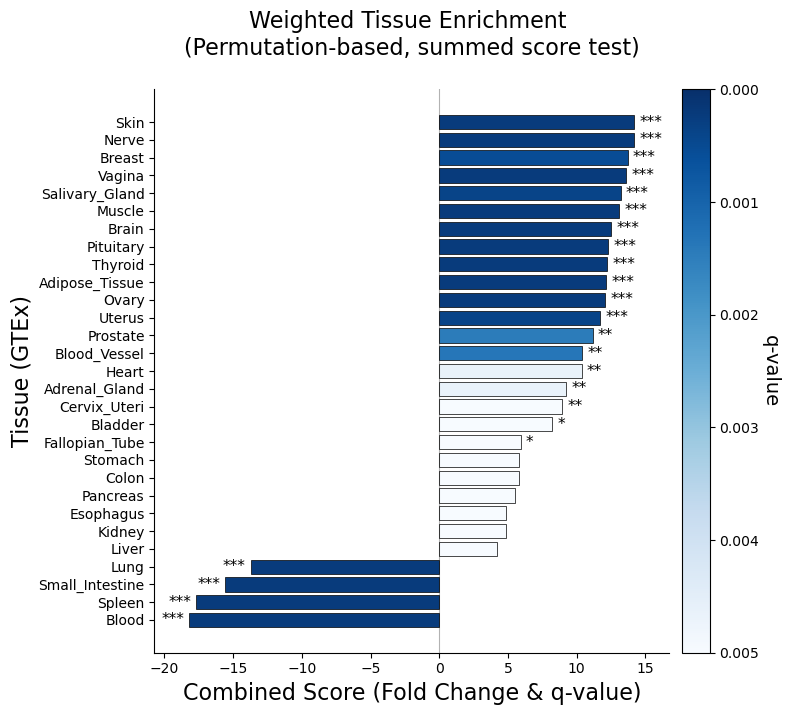

In [7]:
#this is using the permutation test - showing a change in net score (increased - decreased)
net_p = te.make_scores(
    net,
    lfc_col="fold_signed",     
    p_col="p_dir_perm",        
    use_padj=True,
    padj_col="FDR_dir_perm",  
    positive_only=False,      
    z_cap=10.0
).sort_values("combined_score", ascending=False).reset_index(drop=True)

te.plot_tissue_enrichment(net_p, 
                       tissue_col = "tissue",
                        score_col = "combined_score",
                        fdr_col= "FDR_dir_perm",
                        cmap="Blues_r",  
                        max_fdr_shown= 0.005,   
                        figsize_per_bar = 0.25,
                        title='Weighted Tissue Enrichment \n(Permutation-based, summed score test)',
                        savepath="applied_depletion_gregor_n100/paper_figures/depletion_both_signed_tissue_enrichment_bars_PERM.png")

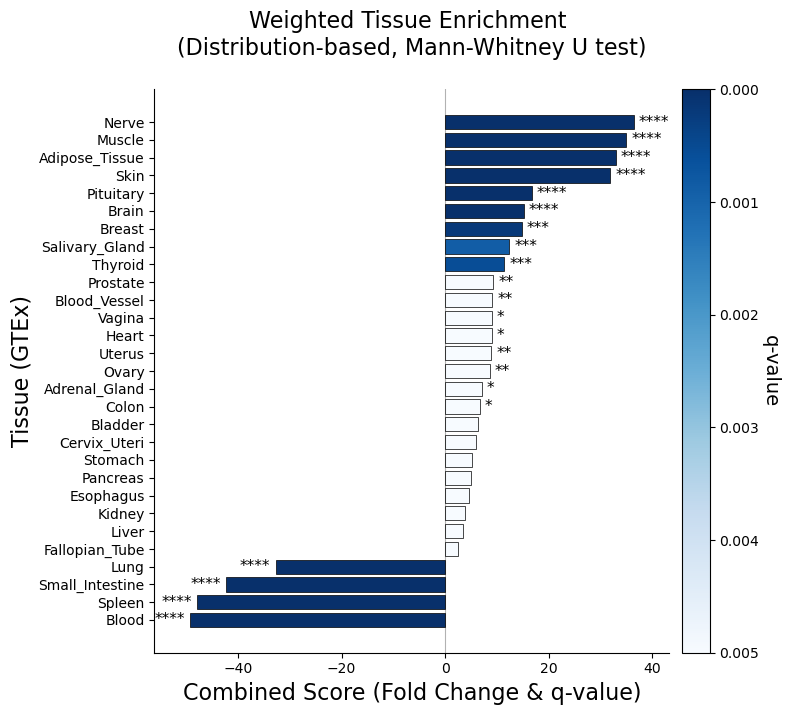

In [8]:
#this is using the mann whitney test - showing a change in distribution
net_mw = te.make_scores(
    net,
    lfc_col="fold_signed",     
    p_col="p_dir_mw",        
    use_padj=True,
    padj_col="FDR_dir_mw",   
    positive_only=False,      
    z_cap=10.0
).sort_values("combined_score", ascending=False).reset_index(drop=True)

te.plot_tissue_enrichment(net_mw, 
                       tissue_col = "tissue",
                        score_col = "combined_score",
                        fdr_col= "FDR_dir_mw",
                        cmap="Blues_r",  
                        max_fdr_shown= 0.005,  
                        figsize_per_bar = 0.25,
                        title='Weighted Tissue Enrichment \n(Distribution-based, Mann-Whitney U test)',
                        savepath="applied_depletion_gregor_n100/paper_figures/depletion_both_signed_tissue_enrichment_bars_MW.png")

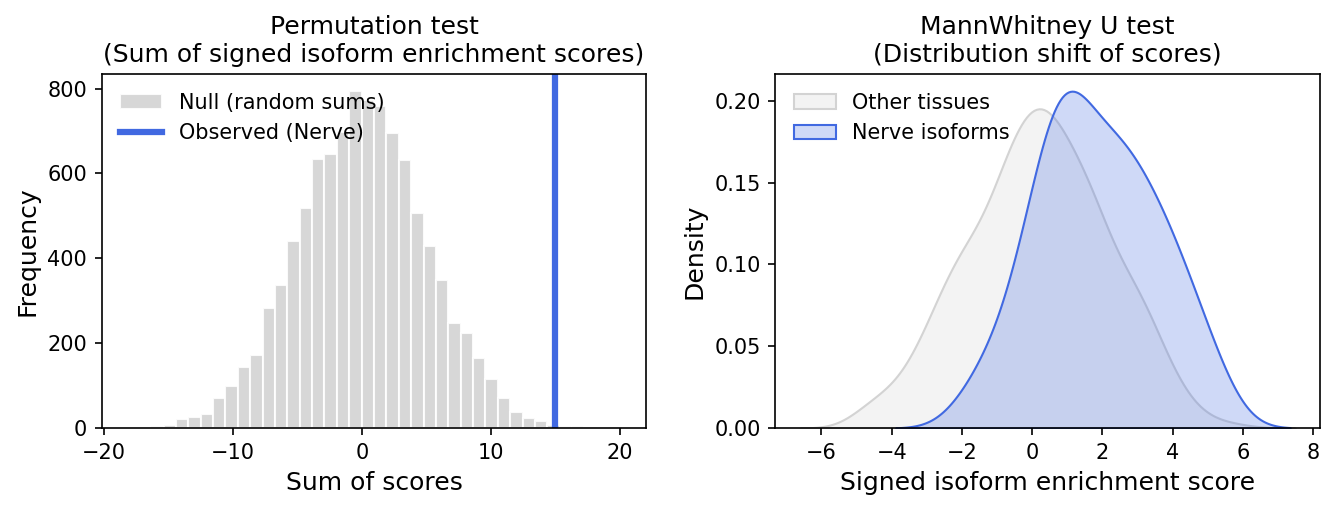

In [ ]:
# general schematic showing the two tests
np.random.seed(1)


# Simulate null distribution (permutation test)
null_dist = np.random.normal(loc=0, scale=5, size=10000)
observed_sum = 15 # observed brain sum


# Simulate signed isoform scores (MWU test)
brain_scores = np.random.normal(loc=2, scale=2, size=50) # shifted right
other_scores = np.random.normal(loc=0, scale=2, size=300)


# --- Plot setup ---
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), dpi=150)


# --- Panel A: Permutation test (sum of scores) ---
ax = axes[0]
ax.hist(null_dist, bins=40, color='lightgray', edgecolor='white', alpha=0.9, label='Null (random sums)')
ax.axvline(observed_sum, color='royalblue', lw=3, label='Observed (Nerve)')
ax.set_title('Permutation test\n(Sum of signed isoform enrichment scores)', fontsize=12)
ax.set_xlabel('Sum of scores', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(frameon=False, loc='upper left')


# --- Panel B: Mann–Whitney U test (distribution shift) ---
ax = axes[1]
sns.kdeplot(other_scores, fill=True, color='lightgray', label='Other tissues', ax=ax)
sns.kdeplot(brain_scores, fill=True, color='royalblue', label='Nerve isoforms', ax=ax)
ax.set_title('MannWhitney U test\n(Distribution shift of scores)', fontsize=12)
ax.set_xlabel('Signed isoform enrichment score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(frameon=False, loc='upper left')


plt.tight_layout()
plt.savefig("applied_depletion_gregor_n100/paper_figures/depletion_figure4_panels_A_B.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
data = pd.read_csv("applied_depletion_gregor_n100/rsem/DESeq2_D_vs_WM_paired_results_isoforms_with_means.csv")
data['significant'] = np.where(data['padj'] < 0.05, 'significant', 'not significant')
data['Transcript stable ID'] = data['transcript_id'].str.split('.').str[0]  
data

,transcript_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,mean_WM_norm,mean_D_norm,mean_WM_model,mean_D_model,significant,Transcript stable ID
0,ENST00000684628.1,630.096376,1.061378,0.020370,52.104103,0.000000,0.0,407.365690,852.827061,410.077980,885.330870,significant,ENST00000684628
1,ENST00000374003.7,230.221361,-2.913648,0.047160,-61.782624,0.000000,0.0,405.406313,55.036409,417.266456,58.460144,significant,ENST00000374003
2,ENST00000374004.5,248.089106,-5.191762,0.126386,-41.078678,0.000000,0.0,480.348104,15.830107,527.299344,15.225122,significant,ENST00000374004
3,ENST00000374005.8,6619.387425,-2.240697,0.018445,-121.481335,0.000000,0.0,10912.262825,2326.512024,10906.612727,2416.802316,significant,ENST00000374005
4,ENST00000399173.5,1363.700609,-3.283663,0.042424,-77.401034,0.000000,0.0,2464.908649,262.492569,2522.719125,269.535298,significant,ENST00000399173
...,...,...,...,...,...,...,...,...,...,...,...,...,...
178322,ENST00000845964.1,0.326832,0.201177,2.898460,0.069408,0.944665,NaN,0.194736,0.458927,0.444522,0.512688,not significant,ENST00000845964
178323,ENST00000802874.1,0.215939,0.264921,2.899169,0.091378,0.927192,NaN,0.157022,0.274856,0.317626,0.403243,not significant,ENST00000802874
178324,ENST00000850737.1,0.165273,-0.696581,2.899714,-0.240224,0.810157,NaN,0.302132,0.028413,0.364466,0.233115,not significant,ENST00000850737
178325,ENST00000492564.2,0.345717,-0.049312,2.898428,-0.017013,0.986426,NaN,0.416450,0.274983,0.482700,0.485175,not significant,ENST00000492564


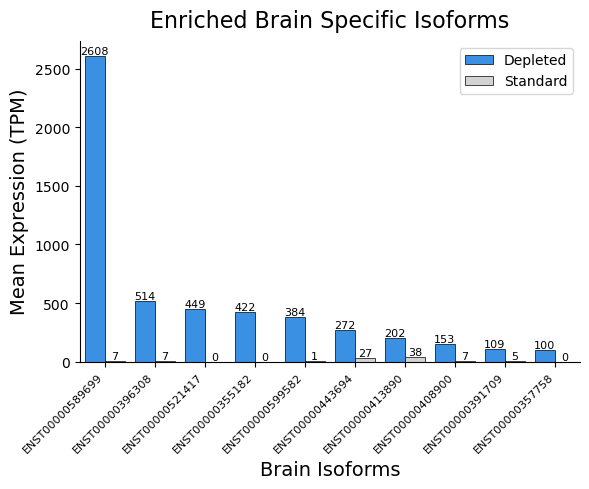

In [15]:
tissue = 'Brain'
ids = tau.loc[tau['primary_tissue'].eq(tissue), 'Transcript stable ID']
sub = data.loc[data['Transcript stable ID'].isin(ids) &
                (data['significant'] == 'significant') &
                (data['log2FoldChange'] > 0)].copy()
sub = sub.sort_values(by='log2FoldChange', ascending=False)
sub = sub.head(20).sort_values(by='mean_D_norm', ascending=False).head(10)

sub_wm = sub[['Transcript stable ID', 'mean_WM_norm']].rename(columns={'mean_WM_norm':'mean_model'})
sub_wm['condition'] = 'Standard'
sub_d = sub[['Transcript stable ID', 'mean_D_norm']].rename(columns={'mean_D_norm':'mean_model'})
sub_d['condition']= 'Depleted'

combined = pd.concat([sub_wm, sub_d])
combined= combined.sort_values(['mean_model','condition'], ascending=False)
combined['mean_model'] = round(combined['mean_model'], 0)

tissue = tissue.replace('_', ' ')
fig, ax = plt.subplots(figsize=(6, 5))
ax = sns.barplot(combined, x="Transcript stable ID", y="mean_model", hue="condition", palette=['dodgerblue', 'lightgrey'],
edgecolor='black', linewidth=0.5)
ax.bar_label(ax.containers[0], fontsize=8)
ax.bar_label(ax.containers[1], fontsize=8)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlabel(f"{tissue} Isoforms", fontsize=14)
plt.ylabel("Mean Expression (TPM)", fontsize=14)
plt.title(f"Enriched {tissue} Specific Isoforms", fontsize=16, pad=10)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig(f"applied_depletion_gregor_n100/paper_figures/{tissue}_specific_isoforms_barplot.png", dpi=300)
plt.show()

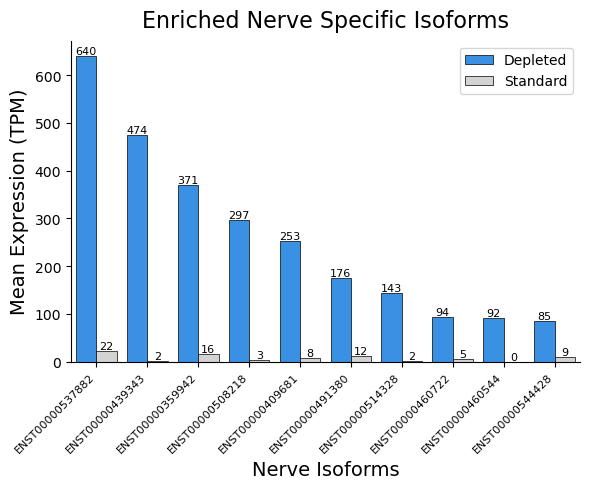

In [16]:
tissue = 'Nerve'
ids = tau.loc[tau['primary_tissue'].eq(tissue), 'Transcript stable ID']
sub = data.loc[data['Transcript stable ID'].isin(ids) &
                (data['significant'] == 'significant') &
                (data['log2FoldChange'] > 0)].copy()
sub = sub.sort_values(by='log2FoldChange', ascending=False)
sub = sub.head(20).sort_values(by='mean_D_norm', ascending=False).head(10)

sub_wm = sub[['Transcript stable ID', 'mean_WM_norm']].rename(columns={'mean_WM_norm':'mean_model'})
sub_wm['condition'] = 'Standard'
sub_d = sub[['Transcript stable ID', 'mean_D_norm']].rename(columns={'mean_D_norm':'mean_model'})
sub_d['condition']= 'Depleted'

combined = pd.concat([sub_wm, sub_d])
combined= combined.sort_values(['mean_model','condition'], ascending=False)
combined['mean_model'] = round(combined['mean_model'], 0)

tissue = tissue.replace('_', ' ')
fig, ax = plt.subplots(figsize=(6, 5))
ax = sns.barplot(combined, x="Transcript stable ID", y="mean_model", hue="condition", palette=['dodgerblue', 'lightgrey'],
edgecolor='black', linewidth=0.5)
ax.bar_label(ax.containers[0], fontsize=8)
ax.bar_label(ax.containers[1], fontsize=8)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlabel(f"{tissue} Isoforms", fontsize=14)
plt.ylabel("Mean Expression (TPM)", fontsize=14)
plt.title(f"Enriched {tissue} Specific Isoforms", fontsize=16, pad=10)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig(f"applied_depletion_gregor_n100/paper_figures/{tissue}_specific_isoforms_barplot.png", dpi=300)
plt.show()

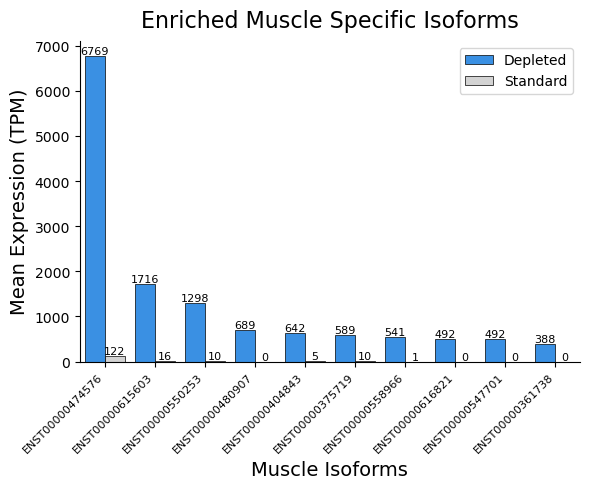

In [17]:
tissue = 'Muscle'
ids = tau.loc[tau['primary_tissue'].eq(tissue), 'Transcript stable ID']
sub = data.loc[data['Transcript stable ID'].isin(ids) &
                (data['significant'] == 'significant') &
                (data['log2FoldChange'] > 0)].copy()
sub = sub.sort_values(by='log2FoldChange', ascending=False)
sub = sub.head(20).sort_values(by='mean_D_norm', ascending=False).head(10)

sub_wm = sub[['Transcript stable ID', 'mean_WM_norm']].rename(columns={'mean_WM_norm':'mean_model'})
sub_wm['condition'] = 'Standard'
sub_d = sub[['Transcript stable ID', 'mean_D_norm']].rename(columns={'mean_D_norm':'mean_model'})
sub_d['condition']= 'Depleted'

combined = pd.concat([sub_wm, sub_d])
combined= combined.sort_values(['mean_model','condition'], ascending=False)
combined['mean_model'] = round(combined['mean_model'], 0)

tissue = tissue.replace('_', ' ')
fig, ax = plt.subplots(figsize=(6, 5))
ax = sns.barplot(combined, x="Transcript stable ID", y="mean_model", hue="condition", palette=['dodgerblue', 'lightgrey'],
edgecolor='black', linewidth=0.5)
ax.bar_label(ax.containers[0], fontsize=8)
ax.bar_label(ax.containers[1], fontsize=8)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlabel(f"{tissue} Isoforms", fontsize=14)
plt.ylabel("Mean Expression (TPM)", fontsize=14)
plt.title(f"Enriched {tissue} Specific Isoforms", fontsize=16, pad=10)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig(f"applied_depletion_gregor_n100/paper_figures/{tissue}_specific_isoforms_barplot.png", dpi=300)
plt.show()

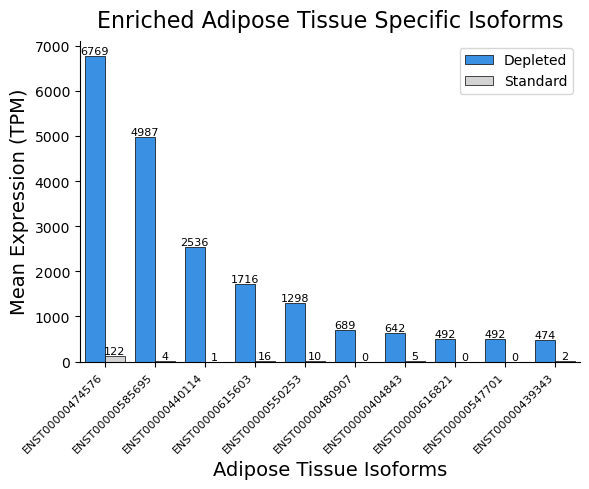

In [18]:
tissue = 'Adipose_Tissue'
ids = tau.loc[tau['primary_tissue'].eq(tissue), 'Transcript stable ID']
sub = data.loc[data['Transcript stable ID'].isin(ids) &
                (data['significant'] == 'significant') &
                (data['log2FoldChange'] > 0)].copy()
sub = sub.sort_values(by='log2FoldChange', ascending=False)
sub = sub.head(20).sort_values(by='mean_D_norm', ascending=False).head(10)

sub_wm = sub[['Transcript stable ID', 'mean_WM_norm']].rename(columns={'mean_WM_norm':'mean_model'})
sub_wm['condition'] = 'Standard'
sub_d = sub[['Transcript stable ID', 'mean_D_norm']].rename(columns={'mean_D_norm':'mean_model'})
sub_d['condition']= 'Depleted'

combined = pd.concat([sub_wm, sub_d])
combined= combined.sort_values(['mean_model','condition'], ascending=False)
combined['mean_model'] = round(combined['mean_model'], 0)

tissue = tissue.replace('_', ' ')
fig, ax = plt.subplots(figsize=(6, 5))
ax = sns.barplot(combined, x="Transcript stable ID", y="mean_model", hue="condition", palette=['dodgerblue', 'lightgrey'],
edgecolor='black', linewidth=0.5)
ax.bar_label(ax.containers[0], fontsize=8)
ax.bar_label(ax.containers[1], fontsize=8)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlabel(f"{tissue} Isoforms", fontsize=14)
plt.ylabel("Mean Expression (TPM)", fontsize=14)
plt.title(f"Enriched {tissue} Specific Isoforms", fontsize=16, pad=10)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig(f"applied_depletion_gregor_n100/paper_figures/{tissue}_specific_isoforms_barplot.png", dpi=300)
plt.show()

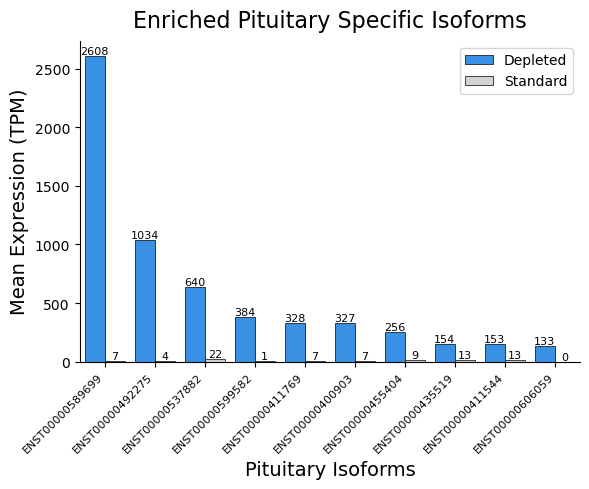

In [19]:
tissue = 'Pituitary'
ids = tau.loc[tau['primary_tissue'].eq(tissue), 'Transcript stable ID']
sub = data.loc[data['Transcript stable ID'].isin(ids) &
                (data['significant'] == 'significant') &
                (data['log2FoldChange'] > 0)].copy()
sub = sub.sort_values(by='log2FoldChange', ascending=False)
sub = sub.head(20).sort_values(by='mean_D_norm', ascending=False).head(10)

sub_wm = sub[['Transcript stable ID', 'mean_WM_norm']].rename(columns={'mean_WM_norm':'mean_model'})
sub_wm['condition'] = 'Standard'
sub_d = sub[['Transcript stable ID', 'mean_D_norm']].rename(columns={'mean_D_norm':'mean_model'})
sub_d['condition']= 'Depleted'

combined = pd.concat([sub_wm, sub_d])
combined= combined.sort_values(['mean_model','condition'], ascending=False)
combined['mean_model'] = round(combined['mean_model'], 0)

tissue = tissue.replace('_', ' ')
fig, ax = plt.subplots(figsize=(6, 5))
ax = sns.barplot(combined, x="Transcript stable ID", y="mean_model", hue="condition", palette=['dodgerblue', 'lightgrey'],
edgecolor='black', linewidth=0.5)
ax.bar_label(ax.containers[0], fontsize=8)
ax.bar_label(ax.containers[1], fontsize=8)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlabel(f"{tissue} Isoforms", fontsize=14)
plt.ylabel("Mean Expression (TPM)", fontsize=14)
plt.title(f"Enriched {tissue} Specific Isoforms", fontsize=16, pad=10)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig(f"applied_depletion_gregor_n100/paper_figures/{tissue}_specific_isoforms_barplot.png", dpi=300)
plt.show()

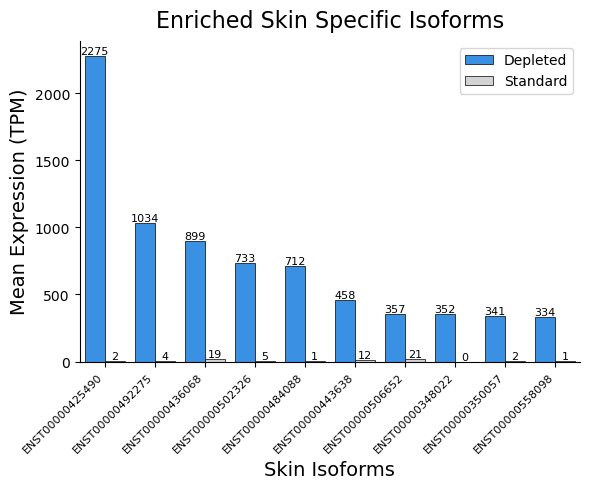

In [20]:
tissue = 'Skin'
ids = tau.loc[tau['primary_tissue'].eq(tissue), 'Transcript stable ID']
sub = data.loc[data['Transcript stable ID'].isin(ids) &
                (data['significant'] == 'significant') &
                (data['log2FoldChange'] > 0)].copy()
sub = sub.sort_values(by='log2FoldChange', ascending=False)
sub = sub.head(20).sort_values(by='mean_D_norm', ascending=False).head(10)

sub_wm = sub[['Transcript stable ID', 'mean_WM_norm']].rename(columns={'mean_WM_norm':'mean_model'})
sub_wm['condition'] = 'Standard'
sub_d = sub[['Transcript stable ID', 'mean_D_norm']].rename(columns={'mean_D_norm':'mean_model'})
sub_d['condition']= 'Depleted'

combined = pd.concat([sub_wm, sub_d])
combined= combined.sort_values(['mean_model','condition'], ascending=False)
combined['mean_model'] = round(combined['mean_model'], 0)

tissue = tissue.replace('_', ' ')
fig, ax = plt.subplots(figsize=(6, 5))
ax = sns.barplot(combined, x="Transcript stable ID", y="mean_model", hue="condition", palette=['dodgerblue', 'lightgrey'],
edgecolor='black', linewidth=0.5)
ax.bar_label(ax.containers[0], fontsize=8)
ax.bar_label(ax.containers[1], fontsize=8)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlabel(f"{tissue} Isoforms", fontsize=14)
plt.ylabel("Mean Expression (TPM)", fontsize=14)
plt.title(f"Enriched {tissue} Specific Isoforms", fontsize=16, pad=10)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig(f"applied_depletion_gregor_n100/paper_figures/{tissue}_specific_isoforms_barplot.png", dpi=300)
plt.show()